In [1]:
user_id = "tp99965073"
domain = "AXISB.COM"
app_name = "Fraud_&_AML"
yarn_queue = "root.DEV.AML_FRAUD_CS"

EXECUTOR_MEMORY=28
EXECUTOR_CORE=4

INITIAL_EXECUTORS=8
MAX_EXECUTORS=50     # 16x4 = 64 cores; lower this to your approved cap if smaller (YARN grants only what is free)
MIN_EXECUTORS=2

In [2]:
import sys
from pyspark.sql import SparkSession, SQLContext
from pyspark import SparkContext, SparkConf
from pyspark.sql import functions as F
from pyspark.sql import Window as W
import pyspark.sql.types as T
from datetime import datetime, date,timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import time
import numpy as np


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))


# Construct the keytab path and the principal
keytab_path = f"/home/{user_id}@axisb.com/{user_id}.keytab"
principal = f"{user_id}@{domain}"

# Execute the commands
!kdestroy
!kinit -k -t "{keytab_path}" {principal}
try:
    spark.stop()
    print("Existing Spark Session Killed")
except:
    print("")
print("Creating new spark session since: ", datetime.now())
spark = SparkSession\
    .builder\
    .appName(f'JH_{user_id}_{app_name}')\
    .config('spark.sql.execution.arrow.enabled', "true")\
    .config('spark.master','yarn')\
    .config('spark.deploy-mode', 'cluster')\
    .config("spark.principal",f"{user_id}@AXISB.COM") \
    .config("spark.keytab",f"{user_id}.keytab")\
    .config('spark.dynamicAllocation.enabled','true') \
    .config('spark.dynamicAllocation.minExecutors',MIN_EXECUTORS) \
    .config('spark.dynamicAllocation.initialExecutors',INITIAL_EXECUTORS) \
    .config('spark.dynamicAllocation.maxExecutors',MAX_EXECUTORS) \
    .config('spark.executor.cores',EXECUTOR_CORE) \
    .config('spark.dynamicAllocation.executorAllocationRatio','0.8')\
    .config('spark.executor.memory',f'{EXECUTOR_MEMORY}g')\
    .config('spark.driver.memory','16g')\
    .config('spark.driver.cores','1')\
    .config('spark.executor.memoryOverhead','8g')\
    .config('spark.sql.shuffle.partitions','12000')\
    .config('spark.shuffle.service.enabled','true')\
    .config('spark.network.timeout','600s')\
    .config('spark.shuffle.io.maxRetries','10')\
    .config('spark.shuffle.io.retryWait','15s')\
    .config('spark.stage.maxConsecutiveAttempts','8')\
    .config('spark.maxRemoteBlockSizeFetchToMem','512m')\
    .config("spark.sql.broadcastTimeout", "-1")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "LEGACY")\
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.int96RebaseModeInWrite", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInWrite", "CORRECTED")\
    .config("spark.yarn.queue", yarn_queue)\
    .config('spark.sql.sources.partitionOverwriteMode', 'dynamic')\
    .config('spark.hadoop.hive.exec.dynamic.partition.mode', 'nonstrict')\
    .config('spark.sql.parquet.output.committer.class', 'org.apache.parquet.hadoop.ParquetOutputCommitter')\
    .config('spark.sql.sources.commitProtocolClass', 'org.apache.spark.sql.execution.datasources.SQLHadoopMapReduceCommitProtocol')\
    .config("spark.jars", "hdfs:///jars/iceberg-spark-runtime-3.3_2.12-1.6.1.jar,/opt/cloudera/parcels/CDH/jars/ojdbc8.jar,Jars/graphframes-0.8.2-spark3.0-s_2.12.jar")\
    .config("spark.graphx.pregel.checkpointInterval", "2")\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions')\
    .config('spark.sql.catalog.spark_catalog', 'org.apache.iceberg.spark.SparkSessionCatalog')\
    .config('spark.sql.catalog.spark_catalog.type', 'hive')\
    .config('spark.sql.adaptive.enabled', 'true')\
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')\
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')\
    .config('spark.sql.adaptive.autoBroadcastJoinThreshold','50MB')\
    .config("spark.sql.legacy.allowNonEmptyLocationInCTAS", "true")\
    .enableHiveSupport()\
    .getOrCreate()
sc = SparkContext.getOrCreate()
print("New Spark Session created at : ", datetime.now())

new_log_level = "ERROR"
sc.setLogLevel(new_log_level)
print(f"Logs level set to {new_log_level}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


Creating new spark session since:  2026-07-08 02:31:26.584045


26/07/08 02:31:27 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 02:31:27 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/08 02:31:28 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 02:31:28 WARN  spark.SparkConf: [Thread-9]: The configuration key 'spark.maxRemoteBlockSizeFetch

New Spark Session created at :  2026-07-08 02:31:39.719369
Logs level set to ERROR


----------------------------------------
Exception happened during processing of request from ('127.0.0.1', 52516)
Traceback (most recent call last):
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 316, in _handle_request_noblock
    self.process_request(request, client_address)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 347, in process_request
    self.finish_request(request, client_address)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 360, in finish_request
    self.RequestHandlerClass(request, client_address, self)
  File "/data1/miniconda3/lib/python3.8/socketserver.py", line 747, in __init__
    self.handle()
  File "/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/accumulators.py", line 282, in handle
    poll(accum_updates)
  File "/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/accumulators.py", line 253, in poll
    if func():
  File "/opt/cloud

# Notebook 04b (v2) — community feature (label propagation) as a SAFE, ISOLATED pass

Runs AFTER 04 (which saved core features: ppr / degree / seed-exposure). Communities (GraphFrames
`labelPropagation` = GraphX **Pregel**) are the step that crashed the 6h run — Pregel piled up RDD lineage
until executors were lost and YARN killed the app. This notebook isolates that step so it can NEVER lose
the PPR work, and fixes the root cause:
  * the session cell sets **`spark.graphx.pregel.checkpointInterval=2`** (Pregel truncates lineage),
  * `LPA_ITERS` is small (4),
  * the result is written to its **own table** `_v2_comm_bad_rate` (we never overwrite `_v2_node_features`),
  * if LPA still fails, just rerun THIS notebook — 04's PPR features are untouched.

Output: `_v2_comm_bad_rate` (id, anchor_month, comm_bad_rate) + a refreshed `_v2_increment_lift` that now
includes the `+community` step. HEAVY — run OFF-HOURS. Run session cells first, then top to bottom.


In [3]:
# ---- PARAMETERS ----
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark import StorageLevel

WRITE_DB = "payment_cards_dev"; EMP = "TP99965073"
EDGES_TXN = f"{WRITE_DB}.{EMP}_v2_edges_transferred"
NODES_ACCT = f"{WRITE_DB}.{EMP}_v2_nodes_account"
SUBG_NIDX = f"{WRITE_DB}.{EMP}_v2_subgraph_node_index"
OWN_TBL  = f"{WRITE_DB}.{EMP}_v2_edges_ownership"   # src=cust, dst=acct (account->customer rollup)
FEATS_CUST = f"{WRITE_DB}.{EMP}_v2_cust_features"   # CUSTOMER-level core features produced by notebook 04 (must exist)

ANCHOR_TRAILING = {
    "202509": ["202506", "202507", "202508"],
    "202510": ["202507", "202508", "202509"],
    "202511": ["202508", "202509", "202510"],
}

TEST_ONE_ANCHOR = False         # FINAL: run all three anchors together (Sep/Oct/Nov)
USE_GRAPHFRAMES = False          # True = GraphFrames LPA (needs pregel.checkpointInterval in session);
                                # False = the DataFrame LPA port (checkpoints every iter — most robust)
RARE_BENEF_MAX  = 20            # keep edges only to beneficiaries with window fan-in <= this (match 04)
LPA_ITERS       = 4
K_PCTS          = [0.01, 0.05, 0.10]

OUT_COMM = f"{WRITE_DB}.{EMP}_v2_comm_bad_rate"
OUT_LIFT = f"{WRITE_DB}.{EMP}_v2_increment_lift"
OUT_CUST_COMM = f"{WRITE_DB}.{EMP}_v2_cust_features_comm"   # 04's customer features + comm_bad_rate (for plots / nb 06)

# 04b works on the SMALL rare-beneficiary graph. The session's spark.sql.shuffle.partitions=12000 is sized for
# 02b's billions-row scan and over-partitions every Pregel/LPA shuffle into ~12000 near-empty tasks on a ~16-slot
# cluster (pure scheduler overhead -> the slowness). 256 is plenty here and makes LPA far faster (identical results).
spark.conf.set("spark.sql.shuffle.partitions", "256")

def save_overwrite(df, t):
    spark.sql("DROP TABLE IF EXISTS " + t); df.write.mode("overwrite").saveAsTable(t)

anchors = (["202509"] if TEST_ONE_ANCHOR else list(ANCHOR_TRAILING.keys()))
print("anchors:", anchors, "| LPA_ITERS:", LPA_ITERS, "| USE_GRAPHFRAMES:", USE_GRAPHFRAMES,
      "| shuffle.partitions:", spark.conf.get("spark.sql.shuffle.partitions"))


anchors: ['202509', '202510', '202511'] | LPA_ITERS: 4 | USE_GRAPHFRAMES: False | shuffle.partitions: 256


## A0. GraphFrames setup + verify the Pregel checkpoint interval is set
**Required for GraphFrames LPA:** the session cell must set `.config("spark.graphx.pregel.checkpointInterval","2")`.
Without it Pregel will crash again. If it prints `<NOT SET>` below, stop, add that config line to the
session cell, restart the session, and re-run — or set `USE_GRAPHFRAMES=False` to use the per-iteration
checkpointed DataFrame LPA instead.


In [4]:
GF_JAR   = "Jars/graphframes-0.8.2-spark3.0-s_2.12.jar"
CKPT_DIR = f"hdfs:///user/{user_id}/gf_ckpt"
spark.sparkContext.setCheckpointDir(CKPT_DIR)
if USE_GRAPHFRAMES:
    try:
        spark.sparkContext.addPyFile(GF_JAR)
        from graphframes import GraphFrame
        pci = spark.conf.get("spark.graphx.pregel.checkpointInterval", "<NOT SET>")
        print("GraphFrames enabled | checkpoint dir:", CKPT_DIR, "| pregel.checkpointInterval =", pci)
        if pci == "<NOT SET>":
            print("*** WARNING: pregel.checkpointInterval NOT set — falling back to DataFrame LPA to be safe.")
            print("*** (To use GraphFrames LPA, add .config(\"spark.graphx.pregel.checkpointInterval\",\"2\") to the session cell.)")
            USE_GRAPHFRAMES = False
    except Exception as ge:
        print("GraphFrames import failed — falling back to DataFrame LPA (per-iteration checkpoint):", ge)
        USE_GRAPHFRAMES = False
if not USE_GRAPHFRAMES:
    print("Using the DataFrame LPA port (per-iteration reliable checkpoint) | checkpoint dir:", CKPT_DIR)


Using the DataFrame LPA port (per-iteration reliable checkpoint) | checkpoint dir: hdfs:///user/tp99965073/gf_ckpt


## A. Substrate (full windowed graph, hub edges dropped) + candidates — same as notebook 04


In [5]:
def build_edges(anchor):
    months = ANCHOR_TRAILING[anchor]
    e0 = (spark.table(EDGES_TXN).where(F.col("txn_month").isin(*months)).select("src", "dst")
          .where(F.col("src") != F.col("dst")).persist(StorageLevel.DISK_ONLY))  # used twice (fan-in + join)
    # KEY FIX (same as 04): keep ONLY rare (private) beneficiaries so communities form around mules, not merchants.
    fanin = e0.groupBy("dst").agg(F.countDistinct("src").alias("fi"))
    rare = fanin.where(F.col("fi") <= RARE_BENEF_MAX).select("dst")
    e = e0.join(rare, "dst", "inner").distinct()
    und = (e.select("src", "dst")
           .union(e.select(F.col("dst").alias("src"), F.col("src").alias("dst")))
           .persist(StorageLevel.DISK_ONLY))
    und.count(); e0.unpersist()                                # materialise und, then free e0
    allnodes = und.select("src").union(und.select(F.col("dst").alias("src"))).distinct().select(F.col("src").alias("id"))
    lab = spark.table(SUBG_NIDX).where(F.col("anchor_month") == anchor)
    seeds = lab.where(F.col("is_known_bad") == 1).select("id").distinct()
    cands = (lab.where((F.col("is_candidate") == 1) & (F.col("is_known_bad") == 0))   # exclude self-seeds (match 04)
             .select("id", F.col("target_fraud").cast("int").alias("target_fraud")))
    return und, allnodes, seeds, cands


## B. DataFrame label-propagation fallback (per-iteration checkpoint — robust on huge graphs)


In [6]:
def label_propagation_df(und, allnodes, iters):
    lab = allnodes.select("id", F.col("id").alias("label"))
    for it in range(iters):
        msgs = (und.alias("u").join(lab.alias("l"), F.col("u.src") == F.col("l.id"))
                .select(F.col("u.dst").alias("id"), F.col("l.label")))
        cnt = msgs.groupBy("id", "label").count()
        w = Window.partitionBy("id").orderBy(F.desc("count"), F.asc("label"))
        new = cnt.withColumn("rn", F.row_number().over(w)).where(F.col("rn") == 1).select("id", "label")
        lab = new.checkpoint(eager=True)   # RELIABLE checkpoint (HDFS) — truncate lineage + survive executor loss
    return lab.select("id", F.col("label").alias("comm"))


def community_bad_rate(comm, seeds):
    # LEAK-FREE: per-community SEED density (historical-bad), NOT candidate target_fraud (that was a leak).
    sc  = comm.join(seeds.select("id"), "id", "inner").groupBy("comm").agg(F.count("*").alias("n_seed"))
    tot = comm.groupBy("comm").agg(F.count("*").alias("n_total"))
    rate = (tot.join(sc, "comm", "left").na.fill(0, ["n_seed"])
            .withColumn("comm_bad_rate", F.col("n_seed") / F.col("n_total")).select("comm", "comm_bad_rate"))
    return comm.join(rate, "comm", "left").na.fill(0.0, ["comm_bad_rate"]).select("id", "comm_bad_rate")


## C. Per anchor — LPA communities -> comm_bad_rate, saved to its own table (durable, isolated)


In [7]:
first_save = True
for a in anchors:
    print("=== community pass:", a, "===")
    und, allnodes, seeds, cands = build_edges(a)
    if USE_GRAPHFRAMES:
        g = GraphFrame(allnodes, und)                      # all edges preserved
        comm = g.labelPropagation(maxIter=LPA_ITERS).select("id", F.col("label").alias("comm"))
    else:
        comm = label_propagation_df(und, allnodes, LPA_ITERS)
    cbr = (community_bad_rate(comm, seeds)                  # seed density (leak-free), not target_fraud
           .join(cands.select("id"), "id", "inner")        # keep candidates only (the scored set)
           .withColumn("anchor_month", F.lit(a))
           .select("id", "anchor_month", "comm_bad_rate"))
    if first_save:
        save_overwrite(cbr, OUT_COMM); first_save = False
    else:
        cbr.write.mode("append").saveAsTable(OUT_COMM)
    print("   saved comm_bad_rate for", a, "->", OUT_COMM)
    und.unpersist()

print("community table:", OUT_COMM, "rows:", spark.table(OUT_COMM).count())


=== community pass: 202509 ===


Hive Session ID = 2b0346db-e221-4e0f-93cb-1e3577873316
                                                                                ]]

   saved comm_bad_rate for 202509 -> payment_cards_dev.TP99965073_v2_comm_bad_rate
=== community pass: 202510 ===


                                                                                ]]

   saved comm_bad_rate for 202510 -> payment_cards_dev.TP99965073_v2_comm_bad_rate
=== community pass: 202511 ===


                                                                                56]]

   saved comm_bad_rate for 202511 -> payment_cards_dev.TP99965073_v2_comm_bad_rate


[Stage 414:======================================================>(76 + 1) / 77]

community table: payment_cards_dev.TP99965073_v2_comm_bad_rate rows: 165685


## D. Refresh the incremental-lift table — now including the +community step


In [8]:
def capture_at(df, score_col, ks):
    w = Window.orderBy(F.col(score_col).desc_nulls_last())
    ranked = df.select("target_fraud", F.row_number().over(w).alias("rk"))
    tot = df.agg(F.count("*").alias("n"), F.sum("target_fraud").alias("nbad")).first()
    n, nbad = tot["n"], (tot["nbad"] or 0)
    rows = []
    for p in ks:
        K = max(1, int(n * p))
        topbad = ranked.where((F.col("rk") <= K) & (F.col("target_fraud") == 1)).count()
        cap = (topbad / nbad) if nbad else 0.0
        lift = ((topbad / K) / (nbad / n)) if nbad else 0.0
        rows.append((p, K, topbad, round(cap, 4), round(lift, 3)))
    return rows, n, nbad

def pr(df, col):
    return df.withColumn("pr_" + col, F.percent_rank().over(Window.orderBy(F.col(col).asc_nulls_first())))

# CUSTOMER level (match 04): roll the account-level community bad-rate up to the customer (max over their
# accounts), then join onto 04's customer-level core features (which had comm_bad_rate=0).
own = spark.table(OWN_TBL).select(F.col("dst").alias("id"), F.col("src").alias("cust"))
comm_cust = (spark.table(OUT_COMM).join(own, "id", "inner")
             .groupBy("cust", "anchor_month").agg(F.max("comm_bad_rate").alias("comm_bad_rate")))
feats_all = (spark.table(FEATS_CUST).drop("comm_bad_rate")
             .join(comm_cust, ["cust", "anchor_month"], "left").na.fill({"comm_bad_rate": 0.0})
             .persist(StorageLevel.DISK_ONLY))
save_overwrite(feats_all, OUT_CUST_COMM)                    # durable customer table WITH comm_bad_rate (for plots / nb 06)
print("saved customer features + communities ->", OUT_CUST_COMM)

INCREMENTS = [("baseline", ["pr_in_deg", "pr_out_deg"]),
              ("+multihop", ["pr_closeness_to_bad"]),
              ("+ppr",      ["pr_ppr"]),
              ("+sharedmule", ["pr_n_shared_mule"]),
              ("+community", ["pr_comm_bad_rate"])]
lift_rows = []
for a in anchors:
    fa = feats_all.where(F.col("anchor_month") == a)
    for c in ["in_deg", "out_deg", "closeness_to_bad", "ppr", "n_shared_mule", "comm_bad_rate"]:
        fa = pr(fa, c)
    included = []
    for step, cols in INCREMENTS:
        included = included + cols
        ens = fa.withColumn("ens", sum(F.col(c) for c in included))
        rows, n, nbad = capture_at(ens.select("target_fraud", "ens"), "ens", K_PCTS)
        for (p, K, topbad, cap, lift) in rows:
            lift_rows.append((a, step, p, K, n, nbad, topbad, cap, lift))
            print("   [%s] %-10s top%4.0f%% K=%d  capture=%.3f  lift=%.2f  (bad-cust %d/%d)"
                  % (a, step, p * 100, K, cap, lift, topbad, nbad))

lift_df = spark.createDataFrame(
    lift_rows, ["anchor_month", "step", "top_pct", "K", "n_cust", "n_bad_cust", "bad_in_topK", "capture", "lift"])
save_overwrite(lift_df, OUT_LIFT)
print("refreshed incremental-lift log (CUSTOMER level, with +community):", OUT_LIFT)
spark.table(OUT_LIFT).orderBy("anchor_month", "step", "top_pct").show(60, False)


saved customer features + communities -> payment_cards_dev.TP99965073_v2_cust_features_comm


   [202509] baseline   top   1% K=625  capture=0.000  lift=0.00  (bad-cust 0/97)
   [202509] baseline   top   5% K=3129  capture=0.062  lift=1.24  (bad-cust 6/97)
   [202509] baseline   top  10% K=6259  capture=0.083  lift=0.82  (bad-cust 8/97)


   [202509] +multihop  top   1% K=625  capture=0.021  lift=2.06  (bad-cust 2/97)
   [202509] +multihop  top   5% K=3129  capture=0.093  lift=1.86  (bad-cust 9/97)
   [202509] +multihop  top  10% K=6259  capture=0.113  lift=1.13  (bad-cust 11/97)


   [202509] +ppr       top   1% K=625  capture=0.031  lift=3.10  (bad-cust 3/97)
   [202509] +ppr       top   5% K=3129  capture=0.083  lift=1.65  (bad-cust 8/97)
   [202509] +ppr       top  10% K=6259  capture=0.134  lift=1.34  (bad-cust 13/97)


   [202509] +sharedmule top   1% K=625  capture=0.051  lift=5.16  (bad-cust 5/97)
   [202509] +sharedmule top   5% K=3129  capture=0.103  lift=2.06  (bad-cust 10/97)
   [202509] +sharedmule top  10% K=6259  capture=0.155  lift=1.55  (bad-cust 15/97)


...

   [202510] +sharedmule top   1% K=637  capture=0.063  lift=6.32  (bad-cust 6/95)
   [202510] +sharedmule top   5% K=3189  capture=0.095  lift=1.90  (bad-cust 9/95)
   [202510] +sharedmule top  10% K=6378  capture=0.168  lift=1.68  (bad-cust 16/95)


   [202510] +community top   1% K=637  capture=0.063  lift=6.32  (bad-cust 6/95)
   [202510] +community top   5% K=3189  capture=0.095  lift=1.90  (bad-cust 9/95)
   [202510] +community top  10% K=6378  capture=0.168  lift=1.68  (bad-cust 16/95)


   [202511] baseline   top   1% K=569  capture=0.000  lift=0.00  (bad-cust 0/54)
   [202511] baseline   top   5% K=2845  capture=0.056  lift=1.11  (bad-cust 3/54)
   [202511] baseline   top  10% K=5690  capture=0.074  lift=0.74  (bad-cust 4/54)
   [202511] +multihop  top   1% K=569  capture=0.000  lift=0.00  (bad-cust 0/54)
   [202511] +multihop  top   5% K=2845  capture=0.037  lift=0.74  (bad-cust 2/54)
   [202511] +multihop  top  10% K=5690  capture=0.074  lift=0.74  (bad-cust 4/54)
   [202511] +ppr       top   1% K=569  capture=0.000  lift=0.00  (bad-cust 0/54)
   [202511] +ppr       top   5% K=2845  capture=0.037  lift=0.74  (bad-cust 2/54)
   [202511] +ppr       top  10% K=5690  capture=0.111  lift=1.11  (bad-cust 6/54)
   [202511] +sharedmule top   1% K=569  capture=0.018  lift=1.85  (bad-cust 1/54)
   [202511] +sharedmule top   5% K=2845  capture=0.056  lift=1.11  (bad-cust 3/54)
   [202511] +sharedmule top  10% K=5690  capture=0.111  lift=1.11  (bad-cust 6/54)


   [202511] +community top   1% K=569  capture=0.018  lift=1.85  (bad-cust 1/54)
   [202511] +community top   5% K=2845  capture=0.056  lift=1.11  (bad-cust 3/54)
   [202511] +community top  10% K=5690  capture=0.111  lift=1.11  (bad-cust 6/54)


refreshed incremental-lift log (CUSTOMER level, with +community): payment_cards_dev.TP99965073_v2_increment_lift
+------------+-----------+-------+----+------+----------+-----------+-------+-----+
|anchor_month|step       |top_pct|K   |n_cust|n_bad_cust|bad_in_topK|capture|lift |
+------------+-----------+-------+----+------+----------+-----------+-------+-----+
|202509      |+community |0.01   |625 |62597 |97        |6          |0.0619 |6.195|
|202509      |+community |0.05   |3129|62597 |97        |11         |0.1134 |2.269|
|202509      |+community |0.1    |6259|62597 |97        |16         |0.1649 |1.65 |
|202509      |+multihop  |0.01   |625 |62597 |97        |2          |0.0206 |2.065|
|202509      |+multihop  |0.05   |3129|62597 |97        |9          |0.0928 |1.856|
|202509      |+multihop  |0.1    |6259|62597 |97        |11         |0.1134 |1.134|
|202509      |+ppr       |0.01   |625 |62597 |97        |3          |0.0309 |3.098|
|202509      |+ppr       |0.05   |3129|62597 |9

## E. Binning + sloping on the COMPLETE feature set (so comm_bad_rate is also tested — mentor's method)


In [9]:
SLOPING_FEATURES = ["n_shared_mule", "shares_mule", "ppr", "closeness_to_bad", "comm_bad_rate", "in_deg", "out_deg"]
OUT_SLOPE = f"{WRITE_DB}.{EMP}_v2_feature_sloping"

def _woe_iv(cnt, bad):
    import numpy as np
    good = cnt - bad
    tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6) if tb else bad * 0 + 1e-6
    pg = (good / tg).clip(lower=1e-6) if tg else good * 0 + 1e-6
    return float(((pg - pb) * np.log(pg / pb)).sum())

import numpy as np
import pandas as pd

def _robust_bins(x, max_bins=10):
    # Zero-inflation-safe, ortools-INDEPENDENT binning (see 04 §J). optbinning's CP solver is broken here
    # (ortools 9.4 < 9.5) and its pre-binning collapses ~99%-zero features to ONE bin (IV=0 despite real
    # lift). Dedicated bin for the dominant 0; one bin per value for low-cardinality counts; else quantile
    # the non-zero tail.
    s = pd.Series(np.asarray(x, dtype=float))
    nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1:
        return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0)
    out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"),
                     q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values
        return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

pdf = feats_all.select("anchor_month", "target_fraud", *SLOPING_FEATURES).toPandas()
slope_rows = []
for a in sorted(pdf["anchor_month"].unique()):
    d = pdf[pdf["anchor_month"] == a]
    y = d["target_fraud"].astype(int).values
    tot_bad = int(y.sum())
    print("=== sloping @ %s (bad=%d / n=%d) ===" % (a, tot_bad, len(d)))
    for f in SLOPING_FEATURES:
        x = d[f].astype(float)
        try:
            bb = _robust_bins(x.values, max_bins=10)
            g = pd.DataFrame({"b": bb, "y": y}).groupby("b").agg(cnt=("y", "size"), bad=("y", "sum")).sort_index()
            g["event_rate_pct"] = 100.0 * g["bad"] / g["cnt"]
            g["pct_fraud_captured"] = (100.0 * g["bad"] / tot_bad) if tot_bad else 0.0
            iv = _woe_iv(g["cnt"], g["bad"])
            er = g["event_rate_pct"].values
            mono = bool(np.all(np.diff(er) >= -1e-9) or np.all(np.diff(er) <= 1e-9))
            print("  %-18s IV=%.3f  bins=%d  monotonic=%s" % (f, iv, len(g), mono))
            for bi, r in g.reset_index().iterrows():
                slope_rows.append((a, f, int(r["b"]) if pd.notna(r["b"]) else -1,
                                   int(r["cnt"]), int(r["bad"]), round(float(r["event_rate_pct"]), 4),
                                   round(float(r["pct_fraud_captured"]), 4), round(iv, 4), mono))
        except Exception as fe:
            print("  %-18s sloping skipped: %s" % (f, fe))
if slope_rows:
    sdf = spark.createDataFrame(slope_rows, ["anchor_month", "feature", "bin", "cnt", "bad",
                                             "event_rate_pct", "pct_fraud_captured", "iv", "monotonic"])
    save_overwrite(sdf, OUT_SLOPE)
    print("saved full sloping (all features incl. comm_bad_rate):", OUT_SLOPE)


=== sloping @ 202509 (bad=97 / n=62597) ===
  n_shared_mule      IV=0.365  bins=9  monotonic=False
  shares_mule        IV=0.197  bins=2  monotonic=True
  ppr                IV=0.093  bins=10  monotonic=False
  closeness_to_bad   IV=0.237  bins=4  monotonic=True
  comm_bad_rate      IV=0.590  bins=10  monotonic=False
  in_deg             IV=0.056  bins=10  monotonic=False
  out_deg            IV=0.209  bins=10  monotonic=False
=== sloping @ 202510 (bad=95 / n=63785) ===
  n_shared_mule      IV=0.263  bins=7  monotonic=False
  shares_mule        IV=0.130  bins=2  monotonic=True
  ppr                IV=0.218  bins=10  monotonic=False
  closeness_to_bad   IV=0.250  bins=4  monotonic=False
  comm_bad_rate      IV=0.098  bins=5  monotonic=False
  in_deg             IV=0.532  bins=10  monotonic=False
  out_deg            IV=0.179  bins=10  monotonic=False
=== sloping @ 202511 (bad=54 / n=56904) ===
  n_shared_mule      IV=0.016  bins=7  monotonic=False
  shares_mule        IV=0.012  bins=2  

saved full sloping (all features incl. comm_bad_rate): payment_cards_dev.TP99965073_v2_feature_sloping


## Done


In [10]:
print("NOTEBOOK 04b (v2) COMPLETE — community bad-rate computed safely (isolated from PPR).")
print("Tables:", OUT_COMM, "(comm_bad_rate) |", OUT_LIFT, "(lift incl. +community).")
print("06 joins core features (_v2_node_features) + community (_v2_comm_bad_rate) for the final score.")
print("Watch whether +community ADDS capture@5% over +ppr; if not, drop it (incremental-then-select).")


NOTEBOOK 04b (v2) COMPLETE — community bad-rate computed safely (isolated from PPR).
Tables: payment_cards_dev.TP99965073_v2_comm_bad_rate (comm_bad_rate) | payment_cards_dev.TP99965073_v2_increment_lift (lift incl. +community).
06 joins core features (_v2_node_features) + community (_v2_comm_bad_rate) for the final score.
Watch whether +community ADDS capture@5% over +ppr; if not, drop it (incremental-then-select).


## FINAL. Binning + gains PLOTS — riskiest bin first, sparse bins clubbed, Wilson lower bound, KS printed
Self-contained: reads the saved table and re-bins on the driver (tiny). Display-only — safe to rerun any time.
Bars = event rate % (riskiest bin on the LEFT, so bars descend); line = cumulative % fraud captured (rises to 100%).
Hatched bar = UNSTABLE bin (too few customers/frauds to trust the rate); event_rate_LCB_% = 95% Wilson lower bound.


plotting anchor 202509 | customers=62597 | frauds=97


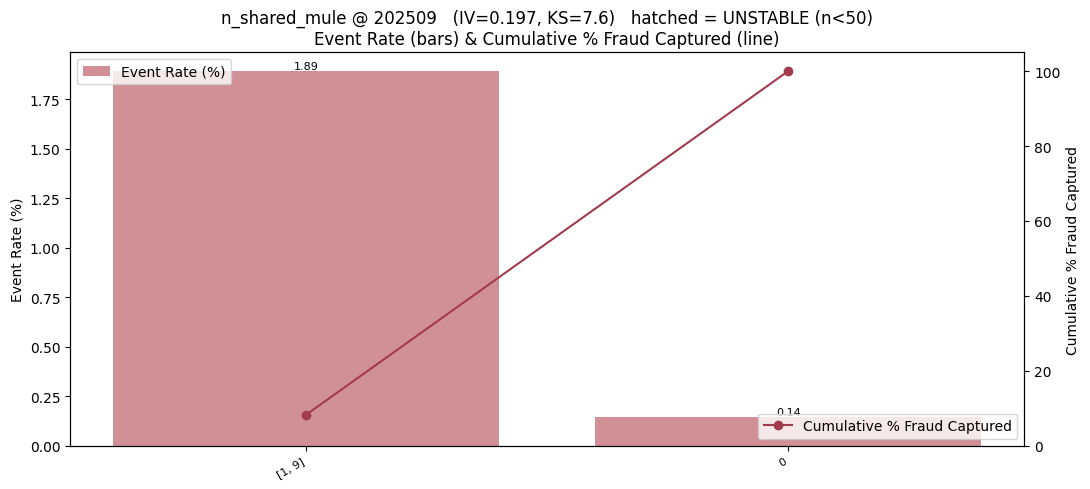

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[1, 9]",8,423,1.891,0.96,8.25,True
1,0,89,62174,0.143,0.12,100.00,True


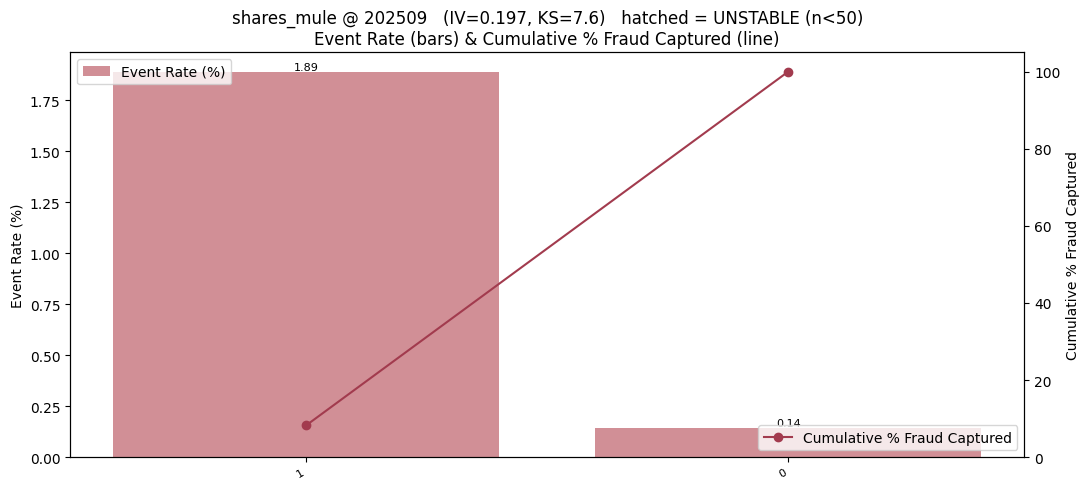

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,1,8,423,1.891,0.96,8.25,True
1,0,89,62174,0.143,0.12,100.00,True


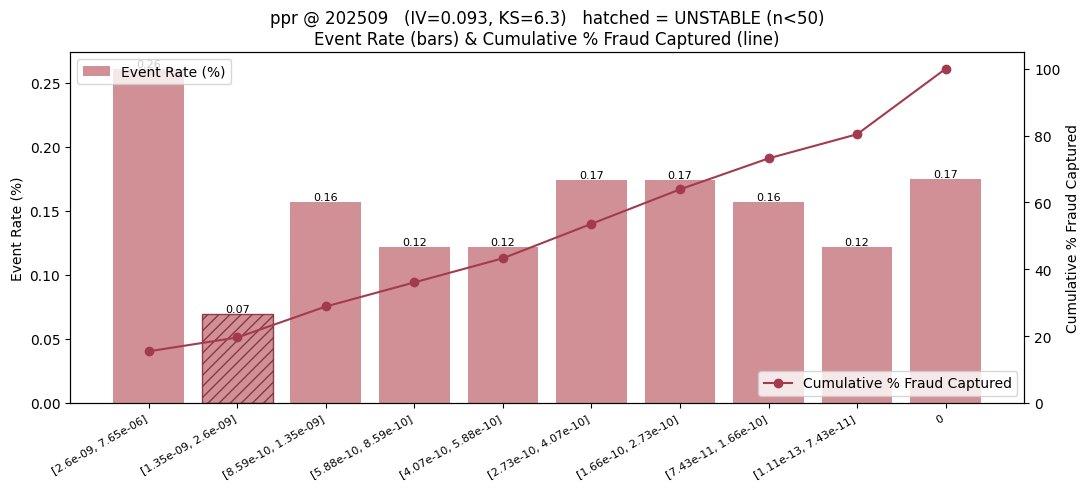

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[2.6e-09, 7.65e-06]",15,5748,0.261,0.16,15.46,True
1,"[1.35e-09, 2.6e-09]",4,5748,0.070,0.03,19.59,False
2,"[8.59e-10, 1.35e-09]",9,5747,0.157,0.08,28.87,True
3,"[5.88e-10, 8.59e-10]",7,5748,0.122,0.06,36.08,True
4,"[4.07e-10, 5.88e-10]",7,5747,0.122,0.06,43.30,True
5,"[2.73e-10, 4.07e-10]",10,5748,0.174,0.09,53.61,True
6,"[1.66e-10, 2.73e-10]",10,5747,0.174,0.09,63.92,True
7,"[7.43e-11, 1.66e-10]",9,5748,0.157,0.08,73.20,True
8,"[1.11e-13, 7.43e-11]",7,5748,0.122,0.06,80.41,True
9,0,19,10868,0.175,0.11,100.00,True


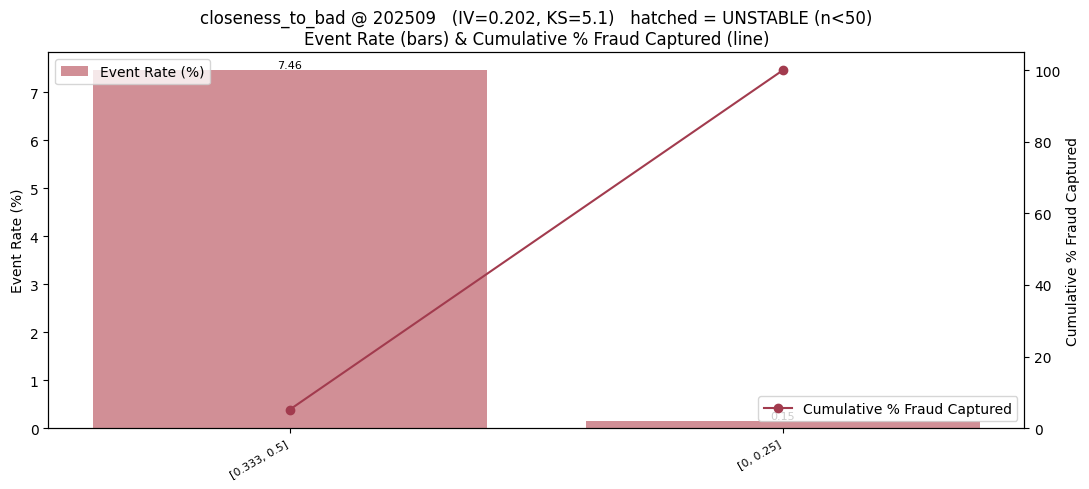

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[0.333, 0.5]",5,67,7.463,3.23,5.15,True
1,"[0, 0.25]",92,62530,0.147,0.12,100.00,True


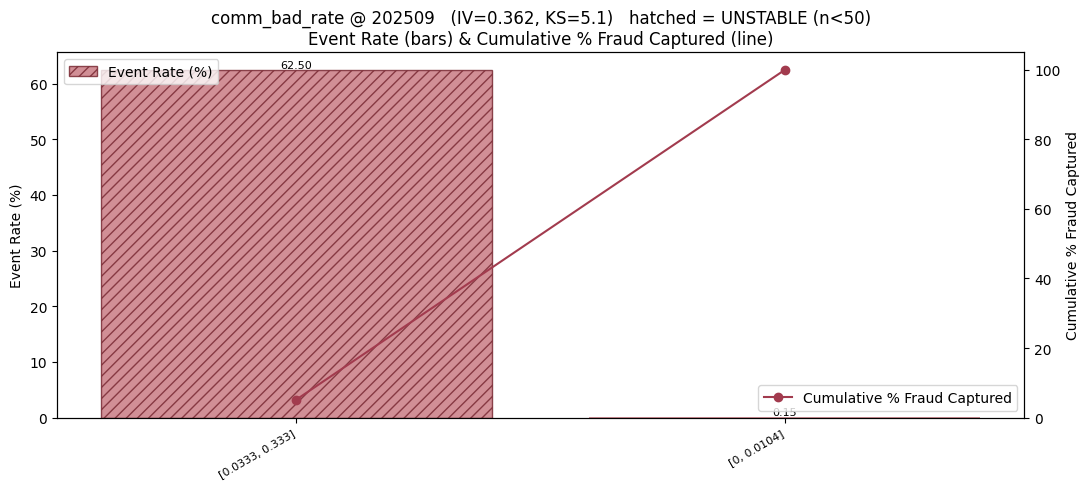

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[0.0333, 0.333]",5,8,62.500,30.57,5.15,False
1,"[0, 0.0104]",92,62589,0.147,0.12,100.00,True


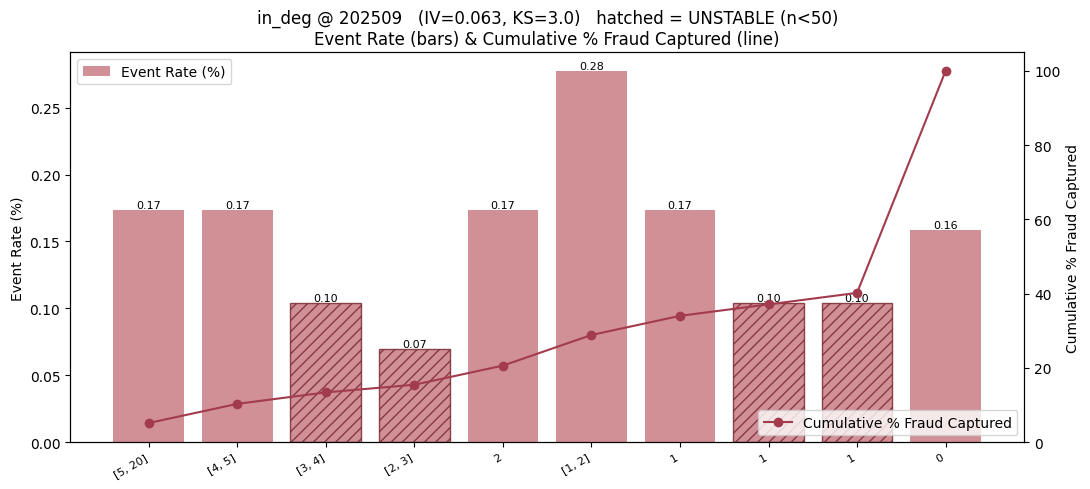

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[5, 20]",5,2884,0.173,0.07,5.15,True
1,"[4, 5]",5,2885,0.173,0.07,10.31,True
2,"[3, 4]",3,2883,0.104,0.04,13.40,False
3,"[2, 3]",2,2884,0.069,0.02,15.46,False
4,2,5,2884,0.173,0.07,20.62,True
5,"[1, 2]",8,2884,0.277,0.14,28.87,True
6,1,5,2884,0.173,0.07,34.02,True
7,1,3,2884,0.104,0.04,37.11,False
8,1,3,2885,0.104,0.04,40.21,False
9,0,58,36640,0.158,0.12,100.00,True


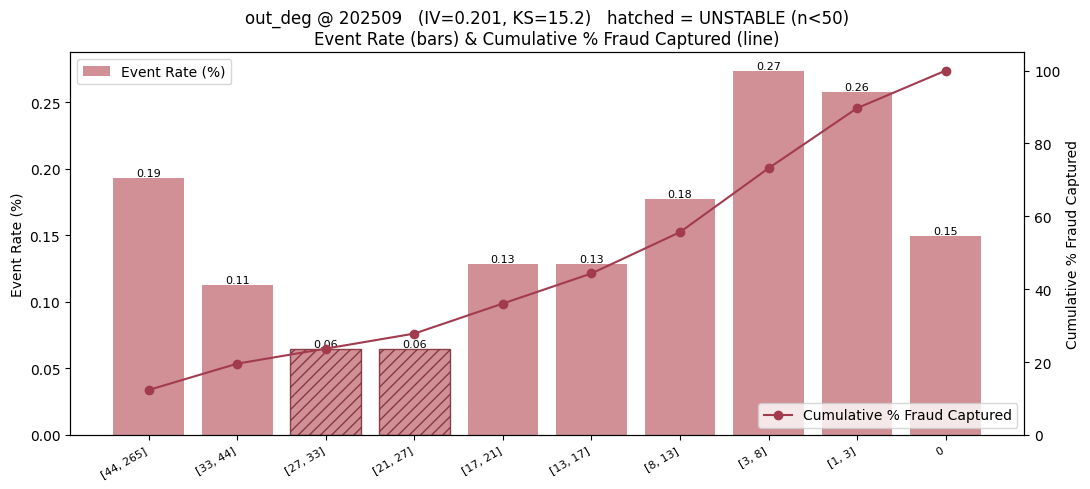

,bin,# frauds,# customers,event_rate_%,event_rate_LCB_%,cum_%_captured,stable
0,"[44, 265]",12,6211,0.193,0.11,12.37,True
1,"[33, 44]",7,6210,0.113,0.05,19.59,True
2,"[27, 33]",4,6210,0.064,0.03,23.71,False
3,"[21, 27]",4,6210,0.064,0.03,27.84,False
4,"[17, 21]",8,6210,0.129,0.07,36.08,True
5,"[13, 17]",8,6210,0.129,0.07,44.33,True
6,"[8, 13]",11,6210,0.177,0.10,55.67,True
7,"[3, 8]",17,6210,0.274,0.17,73.20,True
8,"[1, 3]",16,6211,0.258,0.16,89.69,True
9,0,10,6705,0.149,0.08,100.00,True


In [11]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import IPython.display as _disp
from pyspark.sql import functions as _F

CUST_TBL      = "payment_cards_dev.TP99965073_v2_cust_features_comm"
PLOT_FEATURES = ["n_shared_mule", "shares_mule", "ppr", "closeness_to_bad", "comm_bad_rate", "in_deg", "out_deg"]
PLOT_ANCHOR   = "202509"     # Sep = most matured; change to inspect another anchor
MIN_BIN_FRAC  = 0.01         # club any bin holding < 1% of customers into its neighbour
MIN_STABLE_CNT= 50           # bin with fewer customers than this is flagged UNSTABLE
MIN_STABLE_BAD= 5            # ...or fewer frauds than this
RISKY_ON_LEFT = True         # True = riskiest bin first (decile/gains look); False = feature-value order

def _wilson_lcb(bad, cnt, z=1.96):
    bad = np.asarray(bad, float); cnt = np.asarray(cnt, float)
    p = np.where(cnt > 0, bad / cnt, 0.0); denom = 1 + z*z/np.maximum(cnt, 1)
    centre = p + z*z/(2*np.maximum(cnt, 1)); margin = z*np.sqrt((p*(1-p) + z*z/(4*np.maximum(cnt,1)))/np.maximum(cnt,1))
    return np.where(cnt > 0, np.clip((centre - margin)/denom, 0, 1), 0.0)

def _robust_bins(x, max_bins=10):
    s = pd.Series(np.asarray(x, dtype=float)); nuniq = int(s.nunique(dropna=True))
    if nuniq <= 1: return np.zeros(len(s), dtype=int)
    if nuniq <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), dtype=int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

def _club_sparse(d, n, min_frac):
    d = d.sort_index().copy()
    while len(d) > 2:
        share = d["cnt"] / n
        if share.min() >= min_frac: break
        j = int(share.values.argmin()); k = j + 1 if j == 0 else j - 1
        lo, hi = min(j, k), max(j, k)
        d.loc[d.index[lo], ["cnt", "bad"]] += d.loc[d.index[hi], ["cnt", "bad"]].values
        d.loc[d.index[lo], "hi"] = max(d.loc[d.index[lo], "hi"], d.loc[d.index[hi], "hi"])
        d.loc[d.index[lo], "lo"] = min(d.loc[d.index[lo], "lo"], d.loc[d.index[hi], "lo"])
        d = d.drop(d.index[hi]).reset_index(drop=True)
    return d

def _woe_iv(cnt, bad):
    good = cnt - bad; tb, tg = bad.sum(), good.sum()
    pb = (bad / tb).clip(lower=1e-6); pg = (good / tg).clip(lower=1e-6)
    return float(((pg - pb) * np.log(pg / pb)).sum())

_pdf = spark.table(CUST_TBL).where(_F.col("anchor_month") == PLOT_ANCHOR).select("target_fraud", *PLOT_FEATURES).toPandas()
_y = _pdf["target_fraud"].astype(int).values; _tot_bad = int(_y.sum()); _tot_good = len(_y) - _tot_bad
print("plotting anchor %s | customers=%d | frauds=%d" % (PLOT_ANCHOR, len(_pdf), _tot_bad))

def plot_sloping(feature):
    x = _pdf[feature].astype(float).values
    d = (pd.DataFrame({"b": _robust_bins(x), "x": x, "y": _y}).groupby("b")
         .agg(cnt=("y", "size"), bad=("y", "sum"), lo=("x", "min"), hi=("x", "max")).sort_index())
    d = _club_sparse(d, len(_pdf), MIN_BIN_FRAC)
    d = (d.iloc[::-1] if RISKY_ON_LEFT else d).reset_index(drop=True)
    d["event_rate_pct"] = 100.0 * d["bad"] / d["cnt"]
    cum_bad = d["bad"].cumsum(); cum_good = (d["cnt"] - d["bad"]).cumsum()
    d["pct_captured"] = 100.0 * cum_bad / max(_tot_bad, 1)
    ks = float((100.0 * cum_bad / max(_tot_bad, 1) - 100.0 * cum_good / max(_tot_good, 1)).abs().max())
    iv = _woe_iv(d["cnt"], d["bad"])
    d["er_lcb_pct"] = 100.0 * _wilson_lcb(d["bad"].values, d["cnt"].values)
    d["stable"] = (d["cnt"] >= MIN_STABLE_CNT) & (d["bad"] >= MIN_STABLE_BAD)
    labels = [("%.3g" % lo) if lo == hi else ("[%.3g, %.3g]" % (lo, hi)) for lo, hi in zip(d["lo"], d["hi"])]
    xs = range(len(d))
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.bar(xs, d["event_rate_pct"], color="#c97b84", alpha=0.85, label="Event Rate (%)")
    for i, v in enumerate(d["event_rate_pct"]): ax1.text(i, v, "%.2f" % v, ha="center", va="bottom", fontsize=8)
    ax1.set_ylabel("Event Rate (%)"); ax1.set_xticks(list(xs)); ax1.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    for i, st in enumerate(d["stable"].values):
        if not st: ax1.patches[i].set_hatch("///"); ax1.patches[i].set_edgecolor("#7a2a34")
    ax2 = ax1.twinx()
    ax2.plot(xs, d["pct_captured"], color="#a23b4e", marker="o", label="Cumulative % Fraud Captured")
    ax2.set_ylabel("Cumulative % Fraud Captured"); ax2.set_ylim(0, 105)
    ax1.set_title("%s @ %s   (IV=%.3f, KS=%.1f)   hatched = UNSTABLE (n<%d)\nEvent Rate (bars) & Cumulative %% Fraud Captured (line)"
                  % (feature, PLOT_ANCHOR, iv, ks, MIN_STABLE_CNT), fontsize=12)
    ax1.legend(loc="upper left"); ax2.legend(loc="lower right"); fig.tight_layout(); plt.show()
    _disp.display(pd.DataFrame({"bin": labels, "# frauds": d["bad"].astype(int).values,
                                "# customers": d["cnt"].astype(int).values,
                                "event_rate_%": d["event_rate_pct"].round(3).values,
                                "event_rate_LCB_%": d["er_lcb_pct"].round(2).values,
                                "cum_%_captured": d["pct_captured"].round(2).values,
                                "stable": d["stable"].values}))

for _f in PLOT_FEATURES:
    try: plot_sloping(_f)
    except Exception as _e: print("  %s: skipped (%s)" % (_f, _e))
